# Maroczy quickstart

End-to-end research tour: pull data from LSE, run the research features (bubble detection, covariance cleaning, CPCV, rough volatility), generate characteristics, build a signal, and backtest it. The final section shows how to connect IBKR for live execution.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd

from maroczy.datafeed import LSEData
from maroczy.features import bubble, covariance, cpcv, rough_vol
from maroczy.characteristics import CharacteristicEngine, CharacteristicRegistry
from maroczy.strategy import zscore, long_short_weights, run_backtest

## 1. Connect to LSE

Requires an `LSE_API_KEY` in your `.env` file (copy `.env.example` and fill it in once — `import maroczy` loads it automatically).

In [2]:
lse = LSEData()  # reads LSE_API_KEY from the environment
lse

LSEData(cache=data\cache\lse_data.duckdb)

In [3]:
symbols = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
bars = {s: lse.candles(s, timeframe="1d") for s in symbols}
bars["AAPL"].tail()

,symbol,open,high,low,close,volume
ts,,,,,,
2023-06-05 00:00:00+00:00,AAPL,182.00,184.96,178.03,179.10,56760508
2023-06-06 00:00:00+00:00,AAPL,179.00,180.40,177.43,179.05,33353339
2023-06-07 00:00:00+00:00,AAPL,179.08,181.21,177.32,177.95,40748023
2023-06-08 00:00:00+00:00,AAPL,177.49,180.84,177.12,180.50,28711509
2023-06-09 00:00:00+00:00,AAPL,180.45,182.22,179.90,180.81,31882320


In [4]:
# LSE also covers fundamentals, economics, and options data
income_stmt = lse.financial_reports("AAPL", report_type="income", period="FY")
fundamentals = lse.fundamentals("AAPL")
cpi_yoy = lse.economics("cpi_yoy")
us10y = lse.bond_yields("US10Y", start="2015-01-01")
income_stmt.head()

,id,symbol,report_type,date,fiscal_year,period,reported_currency,data,filing_date,accepted_date,cik,created_at,updated_at
0,1,AAPL,income,2025-09-27,2025,FY,USD,"{'cik': '0000320193', 'eps': 7.49, 'date': '20...",2025-10-31,None,0000320193,2026-01-07T22:26:28Z,2026-07-14T23:00:46Z
1,2,AAPL,income,2024-09-28,2024,FY,USD,"{'cik': '0000320193', 'eps': 6.11, 'date': '20...",2024-11-01,None,0000320193,2026-01-07T22:26:28Z,2026-07-14T23:00:47Z
2,3,AAPL,income,2023-09-30,2023,FY,USD,"{'cik': '0000320193', 'eps': 6.16, 'date': '20...",2023-11-03,None,0000320193,2026-01-07T22:26:28Z,2026-07-14T23:00:47Z
3,4,AAPL,income,2022-09-24,2022,FY,USD,"{'cik': '0000320193', 'eps': 6.15, 'date': '20...",2022-10-28,None,0000320193,2026-01-07T22:26:28Z,2026-07-14T23:00:47Z
4,157705,AAPL,income,2021-09-25,2021,FY,USD,"{'cik': '0000320193', 'eps': 5.67, 'date': '20...",2021-10-29,None,0000320193,2026-01-13T23:00:58Z,2026-07-14T23:00:47Z


## 2. Bubble detection (Phillips, Shi & Yu, 2015)

In [5]:
prices = bars["AAPL"]["close"]

result = bubble.gsadf(prices)
cv = bubble.critical_values(len(prices))
print(f"GSADF stat = {result.stat:.2f}  (95% critical value = {cv['gsadf'][0.95]:.2f})")

episodes = bubble.bsadf_dating(prices, quantile=0.95)
episodes

GSADF stat = 6.85  (95% critical value = 2.41)


,start,end
0,2004-10-28 00:00:00+00:00,2004-11-08 00:00:00+00:00
1,2004-11-22 00:00:00+00:00,2004-12-02 00:00:00+00:00
2,2007-10-22 00:00:00+00:00,2007-11-06 00:00:00+00:00
3,2012-03-09 00:00:00+00:00,2012-04-19 00:00:00+00:00
4,2012-08-17 00:00:00+00:00,2012-09-25 00:00:00+00:00
5,2019-12-26 00:00:00+00:00,2020-02-21 00:00:00+00:00
6,2020-06-29 00:00:00+00:00,2020-10-29 00:00:00+00:00
7,2020-11-03 00:00:00+00:00,2021-02-24 00:00:00+00:00
8,2021-04-05 00:00:00+00:00,2021-05-03 00:00:00+00:00
9,2021-06-22 00:00:00+00:00,2021-09-29 00:00:00+00:00


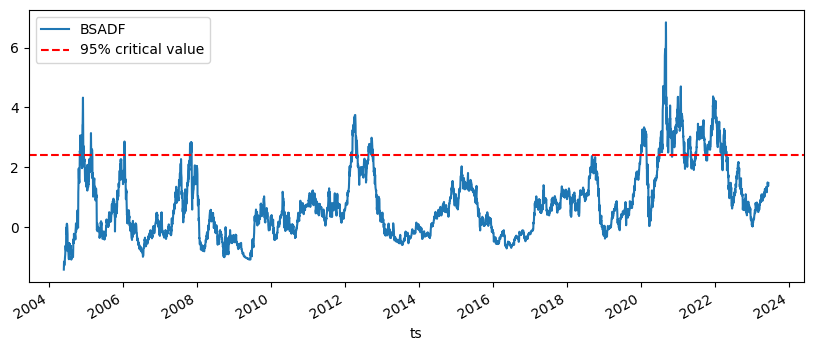

In [6]:
ax = result.bsadf.plot(figsize=(10, 4), label="BSADF")
ax.axhline(cv["gsadf"][0.95], color="red", linestyle="--", label="95% critical value")
ax.legend();

## 3. Covariance matrix cleaning (Bongiorno & Challet, 2022)

In [7]:
rets = pd.DataFrame({s: b["close"].pct_change() for s, b in bars.items()}).dropna()

raw_corr = rets.corr()
cleaned = covariance.clean_covariance(rets, method="cv")
print("condition number, raw:    ", covariance.condition_number(raw_corr))
print("condition number, cleaned:", covariance.condition_number(cleaned))

condition number, raw:     16.898430336260898
condition number, cleaned: 22.538790233085688


## 4. Combinatorial Purged Cross-Validation

In [8]:
cv_splitter = cpcv.CombinatorialPurgedCV(n_groups=6, n_test_groups=2, embargo_frac=0.02)
print(f"{cv_splitter.n_splits} splits, {cv_splitter.n_paths} reconstructable backtest paths")

for split in list(cv_splitter.split(len(rets)))[:3]:
    print(split.test_groups, len(split.train_idx), len(split.test_idx))

15 splits, 5 reconstructable backtest paths
(0, 1) 163 84
(0, 2) 158 84
(0, 3) 158 84


## 5. Rough log-normal volatility (Hager, Horst, Wagenhofer & Xu, 2026)

In [9]:
log_ret = np.log(bars["AAPL"]["close"]).diff().dropna()
realized_log_vol = np.log(log_ret.rolling(21).std().dropna())

H_hat, diagnostics = rough_vol.estimate_hurst(realized_log_vol)
print(f"Estimated Hurst exponent: {H_hat:.3f}")
print(f"Theoretical weak-convergence rate for microstructure MC pricing: {rough_vol.theoretical_weak_rate(max(H_hat, 0.01)):.3f}")

Estimated Hurst exponent: 0.563
Theoretical weak-convergence rate for microstructure MC pricing: 1.000


In [10]:
sim = rough_vol.simulate_rough_bergomi(n_steps=252, n_paths=1000, H=max(H_hat, 0.05), eta=1.5, rho=-0.7, xi0=realized_log_vol.var())
sim["S"][:, -1].mean(), sim["S"][:, -1].std()

(np.float64(0.9946226322451406), np.float64(0.36380097515826143))

## 6. Characteristic generation

In [11]:
registry = CharacteristicRegistry()
print(registry)
registry.names()[:15]

CharacteristicRegistry(57 implemented characteristics)


['age',
 'ami_126d',
 'at_gr1',
 'at_me',
 'beta_60m',
 'beta_dimson_21d',
 'betadown_252d',
 'bidaskhl_21d',
 'capx_gr2',
 'capx_gr3',
 'chmom',
 'corr_1260d',
 'coskew_21d',
 'debt_me',
 'dolvol_126d']

In [12]:
engine = CharacteristicEngine(registry)
mkt_ret = rets.mean(axis=1)  # equal-weight proxy for the market portfolio

panel = engine.compute_universe(
    bars,
    names=["ret_12_1", "ret_1_0", "retvol", "ami_126d", "ivol_capm_21d", "bidaskhl_21d"],
    mkt_ret=mkt_ret,
)
panel.tail(10)

ret_12_1   ret_1_0    retvol  ami_126d  \
ts                        symbol                                           
2026-07-09 00:00:00+00:00 GOOGL   1.087679 -0.019627  0.022177  0.005167   
                          META   -0.162890  0.064335  0.032959  0.001462   
2026-07-10 00:00:00+00:00 GOOGL   1.058824 -0.016983  0.022172  0.005167   
                          META   -0.159400  0.113296  0.034152  0.001462   
2026-07-13 00:00:00+00:00 GOOGL   1.047061 -0.030030  0.022316  0.005167   
                          META   -0.136720  0.058839  0.033950  0.001462   
2026-07-14 00:00:00+00:00 GOOGL   0.968679  0.012327  0.021965  0.005167   
                          META   -0.131422  0.060113  0.033958  0.001460   
2026-07-15 00:00:00+00:00 GOOGL   0.986870  0.031764  0.023024  0.005167   
                          META   -0.182072  0.152753  0.031538  0.001460   

                                  ivol_capm_21d  bidaskhl_21d  
ts                        symbol                               
2026-07-09 00:00:00+00:00 GOOGL             NaN      0.005485  
                          META              NaN      0.010349  
2026-07-10 00:00:00+00:00 GOOGL             NaN      0.006062  
                          META              NaN      0.010349  
2026-07-13 00:00:00+00:00 GOOGL             NaN      0.005660  
                          META              NaN      0.011330  
2026-07-14 00:00:00+00:00 GOOGL             NaN      0.005428  
                          META              NaN      0.011330  
2026-07-15 00:00:00+00:00 GOOGL             NaN      0.005428  
                          META              NaN      0.011330

## 7. Build a signal & backtest it

In [13]:
mom = panel["ret_12_1"].unstack("symbol")
signal_z = zscore(mom, axis=1)

weights = signal_z.apply(lambda row: long_short_weights(row, n_long=2, n_short=2), axis=1)
returns = pd.DataFrame({s: b["close"].pct_change() for s, b in bars.items()})

result = run_backtest(weights, returns, cost_bps=5.0)
result

BacktestResult(sharpe=-0.23, ann_return=-2.62%, ann_vol=11.51%, max_drawdown=-70.01%, avg_turnover=3.51%)

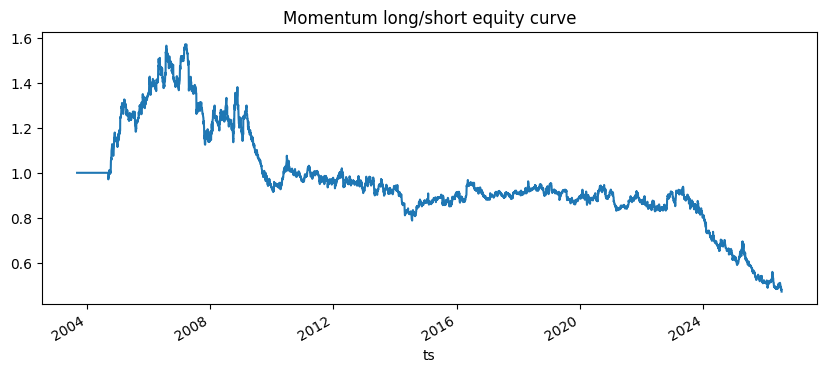

In [14]:
result.equity_curve.plot(figsize=(10, 4), title="Momentum long/short equity curve");

## 8. Production: Live execution via IBKR

When you're ready to trade a signal live, connect to IBKR (requires TWS or IB Gateway running locally with the API enabled). Dry-run by default (`auto=False`) — inspect `.pending_orders` before ever setting `auto=True`.

In [ ]:
from maroczy.broker import Broker, LiveExecutor

broker = Broker()  # host/port/client_id from env vars or defaults (paper port 7497)
broker.connect()

def my_signal(symbol: str) -> float | None:
    return signal_z.iloc[-1].get(symbol)

executor = LiveExecutor(broker=broker, signal_fn=my_signal, capital=10_000, auto=False)
executor.run(symbols)